# AAPL-Only LOBS5 Augmentation for Cross-Market Generalization

This notebook now focuses on the AAPL ticket only.

Workflow:
1. Load AAPL LOBSTER as the target-domain reference.
2. Reconstruct and score LOBS5 synthetic segments against AAPL.
3. Expand the most AAPL-like synthetic segments to create more training data.
4. Fine-tune DeepLOB and Chronos on the augmented AAPL-oriented data.

The notebook is aligned with the existing project notebooks but removes non-AAPL analysis so the full pipeline stays centered on one ticket.

## 1. Setup

In [1]:
%pip install -q huggingface_hub numpy pandas scipy matplotlib seaborn tqdm torch scikit-learn "chronos-forecasting>=2.1.0"


[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python3 -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import copy
import glob
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset

from scipy.stats import ks_2samp, wasserstein_distance
from sklearn.metrics import f1_score, classification_report
from huggingface_hub import hf_hub_download, list_repo_files

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

SEED = 42
rng = np.random.default_rng(SEED)

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Setup complete. Using device: {DEVICE}')

Setup complete. Using device: cpu


/Users/adampeles/Desktop/CIS_7000_Proj/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configuration

In [3]:
# Target domain (AAPL only)
TARGET_TICKER = 'AAPL'
LOBSTER_REPO_ID = 'totalorganfailure/lobster-data'
LOBSTER_FILES = {
    TARGET_TICKER: {
        'orderbook': 'LOBSTER_SampleFile_AAPL_2012-06-21_10/AAPL_2012-06-21_34200000_57600000_orderbook_10.csv',
        'message': 'LOBSTER_SampleFile_AAPL_2012-06-21_10/AAPL_2012-06-21_34200000_57600000_message_10.csv',
    }
}

# Synthetic source (LOB-Bench / LOBS5)
# Note: peernagy/lob_bench currently exposes LOBS5 under GOOG, not AAPL.
LOBS5_REPO_ID = 'peernagy/lob_bench'
LOBS5_TICKER = 'GOOG'
LOBS5_RUN_DIR = 'data_gen_lobs5'
LOBS5_MAX_FILES = 360
LOBS5_AUGMENT_COPIES = 12

# Similarity filtering controls
MIN_EVENTS_PER_SEGMENT = 300
REF_SAMPLE_SIZE = 80000
PER_SEG_SAMPLE_SIZE = 4000
TOP_K_SIMILAR = 30
GENERAL_RANDOM_SEGMENTS = 60
TARGET_HORIZON = 10
MAX_HORIZON = TARGET_HORIZON

# Training controls
WINDOW_SIZE = 100
DEEPLOB_BATCH_SIZE = 256
DEEPLOB_EPOCHS = 8
DEEPLOB_LR = 1e-3
CHRONOS_MODEL_ID = 'amazon/chronos-2'
CHRONOS_CONTEXT_LENGTH = 100
CHRONOS_PREDICTION_LENGTH = TARGET_HORIZON
CHRONOS_BATCH_SIZE = 16
CHRONOS_EPOCHS = 3

# Optional FI-2010 discovery for integration export
FI_CANDIDATE_DIRS = ['data (1)', 'data', 'fi2010_data']

# Output paths
ARTIFACT_DIR = Path('artifacts_adam_lobs5')
ARTIFACT_DIR.mkdir(exist_ok=True)
import os
HF_CACHE_DIR = ARTIFACT_DIR / 'hf_cache'
HF_CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ['HF_HOME'] = str(HF_CACHE_DIR)
os.environ['HF_HUB_CACHE'] = str(HF_CACHE_DIR / 'hub')
(HF_CACHE_DIR / 'hub').mkdir(parents=True, exist_ok=True)

print('Artifacts directory:', ARTIFACT_DIR.resolve())
print('Target ticker:', TARGET_TICKER)
print('Synthetic ticker:', LOBS5_TICKER)

Artifacts directory: /Users/adampeles/Desktop/CIS_7000_Proj/artifacts_adam_lobs5
Target ticker: AAPL
Synthetic ticker: GOOG


## 3. Shared Helper Functions (Aligned with Existing Project Notebooks)

In [4]:
def load_lobster_orderbook(filepath, n_levels=10):
    cols = []
    for i in range(1, n_levels + 1):
        cols += [f'ask_price_{i}', f'ask_vol_{i}', f'bid_price_{i}', f'bid_vol_{i}']
    df = pd.read_csv(filepath, header=None, names=cols)
    price_cols = [c for c in df.columns if 'price' in c]
    df[price_cols] = df[price_cols] / 10000.0
    return df

def load_lobster_message(filepath):
    cols = ['time', 'event_type', 'order_id', 'size', 'price', 'direction']
    df = pd.read_csv(filepath, header=None, names=cols)
    df['price'] = df['price'] / 10000.0
    return df

def compute_lob_features(ob_df, msg_df=None):
    f = pd.DataFrame()
    f['best_ask'] = ob_df['ask_price_1']
    f['best_bid'] = ob_df['bid_price_1']
    f['mid_price'] = (f['best_ask'] + f['best_bid']) / 2.0
    f['spread'] = f['best_ask'] - f['best_bid']
    f['mid_return'] = f['mid_price'].pct_change()

    f['bid_vol_1'] = ob_df['bid_vol_1']
    f['ask_vol_1'] = ob_df['ask_vol_1']
    denom = (f['bid_vol_1'] + f['ask_vol_1']).replace(0, np.nan)
    f['order_imbalance'] = (f['bid_vol_1'] - f['ask_vol_1']) / denom

    bid_vol_cols = [c for c in ob_df.columns if c.startswith('bid_vol_')]
    ask_vol_cols = [c for c in ob_df.columns if c.startswith('ask_vol_')]
    f['total_bid_depth'] = ob_df[bid_vol_cols].sum(axis=1)
    f['total_ask_depth'] = ob_df[ask_vol_cols].sum(axis=1)

    if msg_df is not None and len(msg_df) == len(ob_df):
        f['time'] = msg_df['time']
        f['inter_arrival'] = f['time'].diff()

    f = f.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
    return f

def add_horizon_labels_grouped(df, group_col='segment_id', horizons=(10, 20, 50), eps=1e-5):
    out = df.copy()
    for h in horizons:
        future_mid = out.groupby(group_col)['mid_price'].shift(-h)
        diff = future_mid - out['mid_price']
        out[f'label_h{h}'] = np.where(diff > eps, 3, np.where(diff < -eps, 1, 2))
    return out

def robust_z(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return x
    s = x.std()
    if s == 0 or np.isnan(s):
        return np.zeros_like(x)
    return (x - x.mean()) / s

def subsample(arr, n, seed=0):
    arr = np.asarray(arr)
    if len(arr) <= n:
        return arr
    rr = np.random.default_rng(seed)
    idx = rr.choice(len(arr), size=n, replace=False)
    return arr[idx]

def numeric_feature_cols(df):
    return [
        c for c in df.columns
        if c not in {'segment_id', 'source', 'augmentation_id'}
        and pd.api.types.is_numeric_dtype(df[c])
    ]

def augment_segment_frame(segment_df, copies=1, price_jitter=0.0005, volume_scale=0.15, noise_std=0.01):
    augmented_frames = []
    base_segment_id = str(segment_df['segment_id'].iloc[0])
    base = segment_df.copy()
    numeric_cols = numeric_feature_cols(base)
    for copy_idx in range(copies):
        aug = base.copy()
        if 'mid_price' in aug.columns:
            price_noise = np.random.default_rng(SEED + copy_idx).normal(0.0, price_jitter, size=len(aug))
            aug['mid_price'] = aug['mid_price'] * (1.0 + price_noise)
        if 'best_ask' in aug.columns and 'mid_price' in aug.columns:
            aug['best_ask'] = np.maximum(aug['best_ask'], aug['mid_price'])
        if 'best_bid' in aug.columns and 'mid_price' in aug.columns:
            aug['best_bid'] = np.minimum(aug['best_bid'], aug['mid_price'])
        for col in ['spread', 'order_imbalance', 'mid_return', 'total_bid_depth', 'total_ask_depth', 'ask_vol_1', 'bid_vol_1', 'inter_arrival']:
            if col in aug.columns:
                scale_rng = np.random.default_rng(SEED + 100 + copy_idx)
                jitter_rng = np.random.default_rng(SEED + 200 + copy_idx)
                scale = scale_rng.normal(1.0, volume_scale)
                jitter = jitter_rng.normal(0.0, noise_std, size=len(aug))
                aug[col] = aug[col] * scale + jitter
        aug['segment_id'] = f'{base_segment_id}_aug_{copy_idx:02d}'
        aug['augmentation_id'] = f'{base_segment_id}_aug_{copy_idx:02d}'
        augmented_frames.append(aug)
    return pd.concat(augmented_frames, ignore_index=True) if augmented_frames else segment_df.copy()

def expand_selected_segments(feature_df, selected_segments, copies_per_segment=1):
    pieces = []
    for seg_id in selected_segments:
        seg = feature_df[feature_df['segment_id'] == seg_id].copy()
        if len(seg) == 0:
            continue
        if copies_per_segment > 1:
            pieces.append(augment_segment_frame(seg, copies=copies_per_segment))
        else:
            seg['augmentation_id'] = seg_id + '_base'
            pieces.append(seg)
    if not pieces:
        return feature_df.iloc[0:0].copy()
    return pd.concat(pieces, ignore_index=True)

def build_window_arrays(frame, feature_cols, label_col, window=100, stride=1):
    X, y = [], []
    values = frame[feature_cols].to_numpy(dtype=np.float32)
    labels = frame[label_col].to_numpy(dtype=np.int64)
    for start in range(0, len(frame) - window + 1, stride):
        end = start + window
        X.append(values[start:end])
        y.append(labels[end - 1])
    if not X:
        return np.empty((0, window, len(feature_cols)), dtype=np.float32), np.empty((0,), dtype=np.int64)
    return np.stack(X), np.asarray(y, dtype=np.int64)

def build_windowed_segment_dataset(frame, feature_cols, label_col='label_h10', window=100, stride=1):
    X_parts, y_parts = [], []
    for seg_id, seg in frame.groupby('segment_id', sort=False):
        if len(seg) < window:
            continue
        X_seg, y_seg = build_window_arrays(seg.reset_index(drop=True), feature_cols, label_col, window=window, stride=stride)
        if len(X_seg):
            X_parts.append(X_seg)
            y_parts.append(y_seg)
    if not X_parts:
        return np.empty((0, window, len(feature_cols)), dtype=np.float32), np.empty((0,), dtype=np.int64)
    return np.concatenate(X_parts, axis=0), np.concatenate(y_parts, axis=0)

def make_deeplob_frame(frame):
    cols = ['mid_price', 'spread', 'order_imbalance', 'total_bid_depth', 'total_ask_depth', 'mid_return', 'inter_arrival']
    keep = [c for c in cols if c in frame.columns]
    out = frame[keep + ['segment_id']].copy()
    if 'label_h10' not in frame.columns:
        out['label_h10'] = np.nan
    else:
        out['label_h10'] = frame['label_h10'].values
    return out

def make_chronos_dataframe(frame, segment_col='segment_id', target_col='mid_price'):
    records = []
    for seg_id, seg in frame.groupby(segment_col, sort=False):
        seg = seg.reset_index(drop=True)
        for idx, row in seg.iterrows():
            records.append({
                'item_id': seg_id,
                'timestamp': idx,
                'target': float(row[target_col]),
                'spread': float(row.get('spread', np.nan)),
                'order_imbalance': float(row.get('order_imbalance', np.nan)),
                'total_bid_depth': float(row.get('total_bid_depth', np.nan)),
                'total_ask_depth': float(row.get('total_ask_depth', np.nan)),
            })
    return pd.DataFrame.from_records(records)

## 4. Load LOBSTER Reference Features (Target Domain)

In [5]:
lobster_data = {}
for ticker, paths in LOBSTER_FILES.items():
    lobster_data[ticker] = {}
    for ftype, fpath in paths.items():
        local_path = hf_hub_download(repo_id=LOBSTER_REPO_ID, filename=fpath, repo_type='dataset', cache_dir=str(HF_CACHE_DIR))
        lobster_data[ticker][ftype] = local_path
        print(f'Downloaded {ticker} {ftype}: {local_path}')

lob_ob = load_lobster_orderbook(lobster_data['AAPL']['orderbook'])
lob_msg = load_lobster_message(lobster_data['AAPL']['message'])
lob_feat = compute_lob_features(lob_ob, lob_msg)

print('LOBSTER AAPL features shape:', lob_feat.shape)
display(lob_feat[['mid_price', 'spread', 'mid_return', 'order_imbalance', 'total_bid_depth', 'total_ask_depth']].describe().round(6))

Downloaded AAPL orderbook: artifacts_adam_lobs5/hf_cache/datasets--totalorganfailure--lobster-data/snapshots/fb51a829d2b5a78c79468db533ba28c5f1d161d0/LOBSTER_SampleFile_AAPL_2012-06-21_10/AAPL_2012-06-21_34200000_57600000_orderbook_10.csv


Downloaded AAPL message: artifacts_adam_lobs5/hf_cache/datasets--totalorganfailure--lobster-data/snapshots/fb51a829d2b5a78c79468db533ba28c5f1d161d0/LOBSTER_SampleFile_AAPL_2012-06-21_10/AAPL_2012-06-21_34200000_57600000_message_10.csv


LOBSTER AAPL features shape: (400390, 12)


,mid_price,spread,mid_return,order_imbalance,total_bid_depth,total_ask_depth
count,400390.000000,400390.000000,400390.000000,400390.000000,400390.000000,400390.000000
mean,583.152843,0.153488,-0.000000,0.069744,1828.901721,1496.552911
std,2.834983,0.074154,0.000018,0.569702,1519.247703,1017.586551
min,577.480000,0.010000,-0.000511,-0.999375,165.000000,96.000000
25%,581.245000,0.100000,0.000000,-0.333333,1018.000000,890.000000
50%,583.235000,0.150000,0.000000,0.000000,1372.000000,1178.000000
75%,585.660000,0.200000,0.000000,0.587302,2120.000000,1772.000000
max,588.185000,0.920000,0.000452,0.999513,24629.000000,15962.000000


## 5. Load LOBS5 Message Files and Reconstruct LOB Snapshots

In [6]:
def load_lobs5_messages_and_reconstruct(repo_id, ticker, run_dir, max_files=120, n_levels=10):
    all_files = list_repo_files(repo_id, repo_type='dataset')
    prefix = f'{ticker}/{run_dir}/'
    msg_files = sorted([f for f in all_files if f.startswith(prefix) and '_message_' in f and f.endswith('.csv')])
    if max_files is not None:
        msg_files = msg_files[:max_files]
    if len(msg_files) == 0:
        raise ValueError(f'No LOBS5 message files found under {prefix}')

    def _best_bid(levels):
        return max(levels.keys()) if levels else np.nan

    def _best_ask(levels):
        return min(levels.keys()) if levels else np.nan

    def _add_level(levels, price, delta):
        if not np.isfinite(price) or delta == 0:
            return
        v = levels.get(price, 0.0) + float(delta)
        if v <= 0:
            levels.pop(price, None)
        else:
            levels[price] = v

    def _snapshot(bid_levels, ask_levels):
        snap = {}
        bid_prices = sorted(bid_levels.keys(), reverse=True)[:n_levels]
        ask_prices = sorted(ask_levels.keys())[:n_levels]
        for i in range(1, n_levels + 1):
            bp = bid_prices[i - 1] if i - 1 < len(bid_prices) else np.nan
            ap = ask_prices[i - 1] if i - 1 < len(ask_prices) else np.nan
            snap[f'ask_price_{i}'] = ap
            snap[f'ask_vol_{i}'] = float(ask_levels.get(ap, 0.0)) if np.isfinite(ap) else 0.0
            snap[f'bid_price_{i}'] = bp
            snap[f'bid_vol_{i}'] = float(bid_levels.get(bp, 0.0)) if np.isfinite(bp) else 0.0
        return snap

    def _load_msg(local_path):
        cols = ['time', 'event_type', 'order_id', 'size', 'price', 'direction']
        m = pd.read_csv(local_path, header=None, names=cols)
        med = m['price'].median()
        if np.isfinite(med) and med > 1e4:
            m['price'] = m['price'] / 10000.0
        for c in cols:
            m[c] = pd.to_numeric(m[c], errors='coerce')
        return m

    segments = []
    for i, hf_path in enumerate(msg_files):
        local_path = hf_hub_download(repo_id=repo_id, filename=hf_path, repo_type='dataset', cache_dir=str(HF_CACHE_DIR))
        m = _load_msg(local_path)

        orders = {}
        bid_levels = {}
        ask_levels = {}
        snaps = []

        for _, r in m.iterrows():
            if pd.isna(r['event_type']) or pd.isna(r['order_id']) or pd.isna(r['direction']):
                s = _snapshot(bid_levels, ask_levels)
                s['time'] = r['time']
                snaps.append(s)
                continue

            et = int(r['event_type'])
            oid = int(r['order_id'])
            size = float(r['size']) if np.isfinite(r['size']) else np.nan
            price = float(r['price']) if np.isfinite(r['price']) else np.nan
            direction = int(r['direction'])

            if (not np.isfinite(size)) or (not np.isfinite(price)) or size <= 0:
                s = _snapshot(bid_levels, ask_levels)
                s['time'] = r['time']
                snaps.append(s)
                continue

            if et == 1:
                remaining = size
                if direction == 1:
                    while remaining > 0 and ask_levels:
                        ba = _best_ask(ask_levels)
                        if (not np.isfinite(ba)) or (price < ba):
                            break
                        av = ask_levels[ba]
                        traded = min(remaining, av)
                        av -= traded
                        remaining -= traded
                        if av <= 0:
                            del ask_levels[ba]
                        else:
                            ask_levels[ba] = av
                    if remaining > 0:
                        orders[oid] = (direction, price, remaining)
                        _add_level(bid_levels, price, remaining)
                else:
                    while remaining > 0 and bid_levels:
                        bb = _best_bid(bid_levels)
                        if (not np.isfinite(bb)) or (price > bb):
                            break
                        bv = bid_levels[bb]
                        traded = min(remaining, bv)
                        bv -= traded
                        remaining -= traded
                        if bv <= 0:
                            del bid_levels[bb]
                        else:
                            bid_levels[bb] = bv
                    if remaining > 0:
                        orders[oid] = (direction, price, remaining)
                        _add_level(ask_levels, price, remaining)

            elif et in (2, 4, 5) and oid in orders:
                d0, p0, s0 = orders[oid]
                delta = min(size, s0)
                if d0 == 1:
                    _add_level(bid_levels, p0, -delta)
                else:
                    _add_level(ask_levels, p0, -delta)
                s1 = s0 - delta
                if s1 <= 0:
                    del orders[oid]
                else:
                    orders[oid] = (d0, p0, s1)

            elif et == 3 and oid in orders:
                d0, p0, s0 = orders[oid]
                if d0 == 1:
                    _add_level(bid_levels, p0, -s0)
                else:
                    _add_level(ask_levels, p0, -s0)
                del orders[oid]

            s = _snapshot(bid_levels, ask_levels)
            s['time'] = r['time']
            snaps.append(s)

        seg_df = pd.DataFrame(snaps)
        seg_df['segment_id'] = f'{ticker}_{run_dir}_seg_{i:05d}'
        segments.append(seg_df)

    ob_all = pd.concat(segments, ignore_index=True)
    return ob_all

def compute_lobs5_features_segmented(ob_df, group_col='segment_id'):
    f = pd.DataFrame(index=ob_df.index)
    f[group_col] = ob_df[group_col].values
    f['best_ask'] = ob_df['ask_price_1']
    f['best_bid'] = ob_df['bid_price_1']
    f['mid_price'] = (f['best_ask'] + f['best_bid']) / 2.0
    f['spread'] = f['best_ask'] - f['best_bid']
    f['mid_return'] = f.groupby(group_col)['mid_price'].pct_change()
    f['bid_vol_1'] = ob_df['bid_vol_1']
    f['ask_vol_1'] = ob_df['ask_vol_1']
    denom = (f['bid_vol_1'] + f['ask_vol_1']).replace(0, np.nan)
    f['order_imbalance'] = (f['bid_vol_1'] - f['ask_vol_1']) / denom

    bid_vol_cols = [c for c in ob_df.columns if c.startswith('bid_vol_')]
    ask_vol_cols = [c for c in ob_df.columns if c.startswith('ask_vol_')]
    f['total_bid_depth'] = ob_df[bid_vol_cols].sum(axis=1)
    f['total_ask_depth'] = ob_df[ask_vol_cols].sum(axis=1)

    f['time'] = ob_df['time']
    f['inter_arrival'] = f.groupby(group_col)['time'].diff()
    f = f.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
    return f

In [7]:
lobs5_ob = load_lobs5_messages_and_reconstruct(
    repo_id=LOBS5_REPO_ID,
    ticker=LOBS5_TICKER,
    run_dir=LOBS5_RUN_DIR,
    max_files=LOBS5_MAX_FILES,
    n_levels=10,
)

lobs5_feat = compute_lobs5_features_segmented(lobs5_ob, group_col='segment_id')
lobs5_feat = add_horizon_labels_grouped(lobs5_feat, group_col='segment_id', horizons=(10, 20, 50), eps=1e-5)

print('LOBS5 orderbook shape:', lobs5_ob.shape)
print('LOBS5 features shape:', lobs5_feat.shape)
print('Number of segments:', lobs5_feat['segment_id'].nunique())
display(lobs5_feat[['mid_price', 'spread', 'mid_return', 'order_imbalance', 'total_bid_depth', 'total_ask_depth']].describe().round(6))

LOBS5 orderbook shape: (176404, 42)
LOBS5 features shape: (172486, 16)
Number of segments: 360


,mid_price,spread,mid_return,order_imbalance,total_bid_depth,total_ask_depth
count,172486.000000,172486.000000,172486.000000,172486.000000,172486.000000,172486.000000
mean,89.705247,0.015644,-0.000000,-0.045003,2751.313944,3462.592761
std,0.545816,0.013154,0.000022,0.525494,2005.743499,2223.298999
min,88.465000,0.010000,-0.000560,-0.998578,1.000000,1.000000
25%,89.340000,0.010000,0.000000,-0.476190,1348.000000,1778.000000
50%,89.555000,0.010000,0.000000,-0.051852,2407.000000,3174.000000
75%,89.975000,0.020000,0.000000,0.356223,3686.000000,4807.000000
max,91.545000,0.180000,0.000731,0.998751,21286.000000,25030.000000


In [8]:
import os

print('Running model-driven synthetic augmentation...')

LOBS5_GENERATED_DIR = ARTIFACT_DIR / 'lobs5_generated_rollouts'
LOBS5_GENERATED_DIR.mkdir(parents=True, exist_ok=True)

MODEL_SYNTH_SEGMENTS = 120
MODEL_SYNTH_SEG_LEN = max(MIN_EVENTS_PER_SEGMENT + 80, WINDOW_SIZE + MAX_HORIZON + 120)


def generate_var_synthetic_features(source_df, n_segments, seg_len, seed=42):
    base_cols = [
        'mid_return',
        'spread',
        'order_imbalance',
        'total_bid_depth',
        'total_ask_depth',
    ]
    feature_cols = [c for c in base_cols if c in source_df.columns]
    if len(feature_cols) < 5:
        raise RuntimeError('Insufficient feature columns for synthetic generation.')

    src = source_df[feature_cols].replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
    if len(src) < 2000:
        raise RuntimeError('Not enough source rows to fit the synthetic generator.')

    mu = src.mean(axis=0)
    sigma = src.std(axis=0).replace(0, 1.0)
    z = (src - mu) / sigma

    x = z.iloc[:-1].to_numpy(dtype=np.float64)
    y = z.iloc[1:].to_numpy(dtype=np.float64)
    x_aug = np.hstack([np.ones((x.shape[0], 1), dtype=np.float64), x])

    reg = 1e-3
    xtx = x_aug.T @ x_aug + reg * np.eye(x_aug.shape[1], dtype=np.float64)
    beta = np.linalg.solve(xtx, x_aug.T @ y)

    residuals = y - x_aug @ beta
    cov = np.cov(residuals, rowvar=False)
    cov = np.nan_to_num(cov, nan=0.0, posinf=0.0, neginf=0.0)
    cov = cov + 1e-6 * np.eye(cov.shape[0], dtype=np.float64)
    chol = np.linalg.cholesky(cov)

    local_rng = np.random.default_rng(seed)
    start_pool = z.to_numpy(dtype=np.float64)

    rows = []
    mid_price_pool = source_df['mid_price'].replace([np.inf, -np.inf], np.nan).dropna().to_numpy()
    if len(mid_price_pool) == 0:
        mid_price_pool = np.array([0.0], dtype=np.float64)

    spread_floor = max(1e-6, float(src['spread'].quantile(0.01)))
    bid_floor = max(1e-6, float(src['total_bid_depth'].quantile(0.01)))
    ask_floor = max(1e-6, float(src['total_ask_depth'].quantile(0.01)))
    ret_lo = float(src['mid_return'].quantile(0.001))
    ret_hi = float(src['mid_return'].quantile(0.999))

    for seg_idx in range(n_segments):
        z_prev = start_pool[local_rng.integers(0, len(start_pool))].copy()
        seg_id = f'{LOBS5_TICKER}_model_gen_{seg_idx:05d}'

        seg_rows = []
        for t in range(seg_len):
            noise = local_rng.normal(size=chol.shape[0]) @ chol.T
            z_next = beta[0] + z_prev @ beta[1:] + noise
            val = pd.Series(z_next * sigma.to_numpy() + mu.to_numpy(), index=feature_cols)

            val['order_imbalance'] = float(np.clip(val['order_imbalance'], -0.999, 0.999))
            val['spread'] = float(max(spread_floor, val['spread']))
            val['total_bid_depth'] = float(max(bid_floor, val['total_bid_depth']))
            val['total_ask_depth'] = float(max(ask_floor, val['total_ask_depth']))
            val['mid_return'] = float(np.clip(val['mid_return'], ret_lo, ret_hi))

            seg_rows.append(val)
            z_prev = z_next

        seg_df = pd.DataFrame(seg_rows)
        p0 = float(local_rng.choice(mid_price_pool))
        seg_df['mid_price'] = p0 + seg_df['mid_return'].cumsum()

        if 'inter_arrival' in source_df.columns:
            ia = source_df['inter_arrival'].replace([np.inf, -np.inf], np.nan).dropna().to_numpy()
            if len(ia) > 0:
                ia_sample = local_rng.choice(ia, size=len(seg_df), replace=True)
                seg_df['inter_arrival'] = np.clip(ia_sample, 0.0, np.quantile(ia, 0.995))

        seg_df['segment_id'] = seg_id
        seg_df['time'] = np.arange(len(seg_df), dtype=int)
        rows.append(seg_df)

    synth = pd.concat(rows, ignore_index=True)
    synth = synth.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
    return synth


lobs5_feat_generated = pd.DataFrame()
model_generation_status = 'skipped'

try:
    n_segments = min(MODEL_SYNTH_SEGMENTS, max(40, len(lobs5_feat) // max(MIN_EVENTS_PER_SEGMENT, 1)))
    lobs5_feat_generated = generate_var_synthetic_features(
        lobs5_feat,
        n_segments=n_segments,
        seg_len=MODEL_SYNTH_SEG_LEN,
        seed=SEED + 123,
    )

    lobs5_feat_generated = add_horizon_labels_grouped(
        lobs5_feat_generated,
        group_col='segment_id',
        horizons=(10, 20, 50),
        eps=1e-5,
    )
    lobs5_feat_generated = lobs5_feat_generated.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

    lobs5_feat_generated.to_csv(ARTIFACT_DIR / 'lobs5_generated_features.csv', index=False)

    print('Model-driven generation complete (VAR residual simulator).')
    print('  Synthetic feature shape:', lobs5_feat_generated.shape)
    display(lobs5_feat_generated[['mid_price', 'spread', 'mid_return', 'order_imbalance', 'total_bid_depth', 'total_ask_depth']].describe().round(6))

    lobs5_feat = pd.concat([lobs5_feat, lobs5_feat_generated], ignore_index=True)
    print('  Combined LOBS5 feature pool shape:', lobs5_feat.shape)
    model_generation_status = 'ok'

except Exception as exc:
    print(f'Model-driven generation skipped: {exc}')
    model_generation_status = 'skipped'

print('Generation status:', model_generation_status)
print('Downstream similarity scoring will use the updated LOBS5 feature pool when generation is available.')

Running model-driven synthetic augmentation...


Model-driven generation complete (VAR residual simulator).
  Synthetic feature shape: (45600, 12)


,mid_price,spread,mid_return,order_imbalance,total_bid_depth,total_ask_depth
count,45600.000000,45600.000000,45600.000000,45600.000000,45600.000000,45600.000000
mean,89.758577,0.018315,-0.000000,-0.029618,2898.957130,3640.815497
std,0.591690,0.009501,0.000022,0.503879,1964.197547,2085.403120
min,89.034908,0.010000,-0.000102,-0.999000,100.000000,150.000000
25%,89.345143,0.010000,-0.000015,-0.382410,1414.148100,2122.033877
50%,89.597303,0.015237,-0.000000,-0.033630,2716.931780,3571.649265
75%,89.992660,0.024224,0.000015,0.318102,4110.630981,5043.204242
max,91.465294,0.128579,0.000088,0.999000,15693.866451,11474.881731


  Combined LOBS5 feature pool shape: (218086, 16)
Generation status: ok
Downstream similarity scoring will use the updated LOBS5 feature pool when generation is available.


## 6. Segment-Level Similarity Scoring (LOBS5 -> LOBSTER)

In [9]:
# Build target reference arrays from LOBSTER
ref_ret = robust_z(lob_feat['mid_return'].values)
ref_oi = lob_feat['order_imbalance'].dropna().values
ref_spread = lob_feat['spread'].dropna().values
ref_depth = (lob_feat['total_bid_depth'] + lob_feat['total_ask_depth']).dropna().values

ref_ret = subsample(ref_ret, REF_SAMPLE_SIZE, seed=SEED + 1)
ref_oi = subsample(ref_oi, REF_SAMPLE_SIZE, seed=SEED + 2)
ref_spread = subsample(ref_spread, REF_SAMPLE_SIZE, seed=SEED + 3)
ref_depth = subsample(ref_depth, REF_SAMPLE_SIZE, seed=SEED + 4)

rows = []
for seg_id, seg in lobs5_feat.groupby('segment_id', sort=False):
    if len(seg) < MIN_EVENTS_PER_SEGMENT:
        continue

    s_ret = robust_z(seg['mid_return'].values)
    s_oi = seg['order_imbalance'].dropna().values
    s_spread = seg['spread'].dropna().values
    s_depth = (seg['total_bid_depth'] + seg['total_ask_depth']).dropna().values

    if len(s_ret) < 100 or len(s_oi) < 100 or len(s_spread) < 100:
        continue

    s_ret = subsample(s_ret, PER_SEG_SAMPLE_SIZE, seed=SEED)
    s_oi = subsample(s_oi, PER_SEG_SAMPLE_SIZE, seed=SEED)
    s_spread = subsample(s_spread, PER_SEG_SAMPLE_SIZE, seed=SEED)
    s_depth = subsample(s_depth, PER_SEG_SAMPLE_SIZE, seed=SEED)

    w_ret = float(wasserstein_distance(s_ret, ref_ret))
    w_oi = float(wasserstein_distance(s_oi, ref_oi))
    w_spread = float(wasserstein_distance(s_spread, ref_spread))
    w_depth = float(wasserstein_distance(s_depth, ref_depth))

    ks_ret = float(ks_2samp(s_ret, ref_ret).statistic)
    ks_oi = float(ks_2samp(s_oi, ref_oi).statistic)

    mean_gap = float(abs(seg['mid_return'].mean() - lob_feat['mid_return'].mean()))
    vol_gap = float(abs(seg['mid_return'].std() - lob_feat['mid_return'].std()))

    rows.append({
        'segment_id': seg_id,
        'n_events': int(len(seg)),
        'w_ret': w_ret,
        'w_oi': w_oi,
        'w_spread': w_spread,
        'w_depth': w_depth,
        'ks_ret': ks_ret,
        'ks_oi': ks_oi,
        'mean_gap': mean_gap,
        'vol_gap': vol_gap,
    })

scores = pd.DataFrame(rows)
if len(scores) == 0:
    raise RuntimeError('No valid segments found after filtering. Reduce MIN_EVENTS_PER_SEGMENT.')

# Min-max normalize each metric and combine into one score. Lower is better.
metric_cols = ['w_ret', 'w_oi', 'w_spread', 'w_depth', 'ks_ret', 'ks_oi', 'mean_gap', 'vol_gap']
for c in metric_cols:
    lo, hi = scores[c].min(), scores[c].max()
    if hi > lo:
        scores[c + '_norm'] = (scores[c] - lo) / (hi - lo)
    else:
        scores[c + '_norm'] = 0.0

scores['similarity_score'] = (
    0.25 * scores['w_ret_norm'] +
    0.20 * scores['w_oi_norm'] +
    0.15 * scores['w_spread_norm'] +
    0.10 * scores['w_depth_norm'] +
    0.10 * scores['ks_ret_norm'] +
    0.10 * scores['ks_oi_norm'] +
    0.05 * scores['mean_gap_norm'] +
    0.05 * scores['vol_gap_norm']
)

scores = scores.sort_values('similarity_score', ascending=True).reset_index(drop=True)
display(scores.head(15).round(6))

scores.to_csv(ARTIFACT_DIR / 'lobs5_segment_scores.csv', index=False)
print('Saved:', ARTIFACT_DIR / 'lobs5_segment_scores.csv')

,segment_id,n_events,w_ret,w_oi,w_spread,w_depth,ks_ret,ks_oi,mean_gap,vol_gap,w_ret_norm,w_oi_norm,w_spread_norm,w_depth_norm,ks_ret_norm,ks_oi_norm,mean_gap_norm,vol_gap_norm,similarity_score
0,GOOG_data_gen_lobs5_seg_00274,465,0.122011,0.153495,0.098588,628.737889,0.891268,0.191638,0.000000,0.000012,0.057823,0.126532,0.000000,0.013782,0.943836,0.171659,0.031216,0.304537,0.169477
1,GOOG_data_gen_lobs5_seg_00194,487,0.121612,0.075302,0.121959,972.853834,0.886496,0.105218,0.000000,0.000002,0.057184,0.023362,0.523738,0.042693,0.934292,0.047640,0.012542,0.043719,0.202805
2,GOOG_data_gen_lobs5_seg_00343,389,0.135924,0.319220,0.104549,1314.386377,0.891072,0.280606,0.000000,0.000001,0.080122,0.345194,0.133571,0.071388,0.943445,0.299336,0.067287,0.020953,0.244934
3,GOOG_data_gen_lobs5_seg_00063,477,0.194262,0.080263,0.124512,1295.484989,0.887903,0.099836,0.000001,0.000003,0.173618,0.029908,0.580935,0.069800,0.937107,0.039916,0.274952,0.066669,0.258290
4,GOOG_data_gen_lobs5_seg_00053,476,0.140162,0.057596,0.132729,2953.698693,0.894140,0.072021,0.000000,0.000003,0.086914,0.000000,0.765075,0.209119,0.949580,0.000000,0.101275,0.076849,0.261266
5,GOOG_data_gen_lobs5_seg_00026,496,0.158978,0.130885,0.114280,4009.324833,0.895031,0.179353,0.000000,0.000019,0.117070,0.096700,0.351657,0.297810,0.951363,0.154029,0.114391,0.481773,0.271484
6,GOOG_data_gen_lobs5_seg_00278,478,0.171580,0.076809,0.134446,464.706066,0.890061,0.135639,0.000001,0.000001,0.137266,0.025350,0.803564,0.000000,0.941423,0.091296,0.276945,0.014963,0.277788
7,GOOG_data_gen_lobs5_seg_00231,484,0.141708,0.129531,0.128150,3321.749166,0.894557,0.203349,0.000000,0.000001,0.089391,0.094914,0.662466,0.240041,0.950413,0.188466,0.056064,0.031009,0.282946
8,GOOG_data_gen_lobs5_seg_00155,394,0.166058,0.159774,0.123567,1483.390101,0.901459,0.181181,0.000000,0.000016,0.128416,0.134817,0.559770,0.085587,0.964217,0.156653,0.039525,0.386052,0.284958
9,GOOG_data_gen_lobs5_seg_00131,470,0.160033,0.080176,0.141467,788.399083,0.900076,0.107652,0.000000,0.000000,0.118760,0.029793,0.960902,0.027196,0.961452,0.051133,0.120197,0.006950,0.290119


Saved: artifacts_adam_lobs5/lobs5_segment_scores.csv


In [10]:
top_similar_segments = scores.head(TOP_K_SIMILAR)['segment_id'].tolist()

eligible_segments = scores['segment_id'].tolist()
general_segment_sample = list(rng.choice(eligible_segments, size=min(GENERAL_RANDOM_SEGMENTS, len(eligible_segments)), replace=False))

lobs5_similar = lobs5_feat[lobs5_feat['segment_id'].isin(top_similar_segments)].copy()
lobs5_general = lobs5_feat[lobs5_feat['segment_id'].isin(general_segment_sample)].copy()

# Expand the AAPL-like synthetic pool substantially by generating multiple perturbed copies per segment.
lobs5_similar_expanded = expand_selected_segments(
    lobs5_feat,
    top_similar_segments,
    copies_per_segment=LOBS5_AUGMENT_COPIES,
 )

lobs5_general_expanded = expand_selected_segments(
    lobs5_feat,
    general_segment_sample,
    copies_per_segment=max(2, LOBS5_AUGMENT_COPIES // 3),
 )

print('Similar subset shape:', lobs5_similar.shape)
print('Expanded similar subset shape:', lobs5_similar_expanded.shape)
print('General subset shape:', lobs5_general.shape)
print('Expanded general subset shape:', lobs5_general_expanded.shape)
print('Top similar segments (first 10):', top_similar_segments[:10])

scores.head(TOP_K_SIMILAR).to_csv(ARTIFACT_DIR / 'top_similar_segments.csv', index=False)
lobs5_similar.to_csv(ARTIFACT_DIR / 'lobs5_filtered_similarity_features.csv', index=False)
lobs5_similar_expanded.to_csv(ARTIFACT_DIR / 'lobs5_filtered_similarity_expanded.csv', index=False)
lobs5_general.to_csv(ARTIFACT_DIR / 'lobs5_general_features_sample.csv', index=False)
lobs5_general_expanded.to_csv(ARTIFACT_DIR / 'lobs5_general_expanded_features.csv', index=False)

print('Saved:', ARTIFACT_DIR / 'top_similar_segments.csv')
print('Saved:', ARTIFACT_DIR / 'lobs5_filtered_similarity_features.csv')
print('Saved:', ARTIFACT_DIR / 'lobs5_filtered_similarity_expanded.csv')
print('Saved:', ARTIFACT_DIR / 'lobs5_general_features_sample.csv')
print('Saved:', ARTIFACT_DIR / 'lobs5_general_expanded_features.csv')

Similar subset shape: (14130, 16)
Expanded similar subset shape: (169560, 17)
General subset shape: (27318, 16)
Expanded general subset shape: (109272, 17)
Top similar segments (first 10): ['GOOG_data_gen_lobs5_seg_00274', 'GOOG_data_gen_lobs5_seg_00194', 'GOOG_data_gen_lobs5_seg_00343', 'GOOG_data_gen_lobs5_seg_00063', 'GOOG_data_gen_lobs5_seg_00053', 'GOOG_data_gen_lobs5_seg_00026', 'GOOG_data_gen_lobs5_seg_00278', 'GOOG_data_gen_lobs5_seg_00231', 'GOOG_data_gen_lobs5_seg_00155', 'GOOG_data_gen_lobs5_seg_00131']


Saved: artifacts_adam_lobs5/top_similar_segments.csv
Saved: artifacts_adam_lobs5/lobs5_filtered_similarity_features.csv
Saved: artifacts_adam_lobs5/lobs5_filtered_similarity_expanded.csv
Saved: artifacts_adam_lobs5/lobs5_general_features_sample.csv
Saved: artifacts_adam_lobs5/lobs5_general_expanded_features.csv


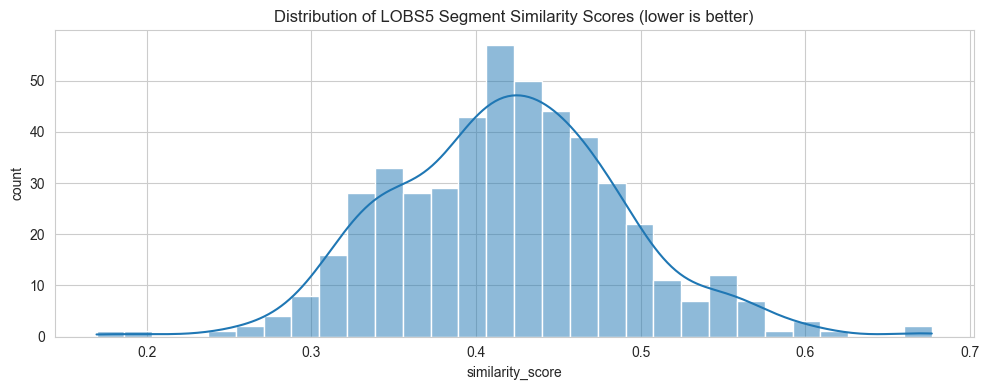

,segment_id,similarity_score,w_ret,w_oi,w_spread,ks_ret,ks_oi
0,GOOG_data_gen_lobs5_seg_00274,0.169477,0.122011,0.153495,0.098588,0.891268,0.191638
1,GOOG_data_gen_lobs5_seg_00194,0.202805,0.121612,0.075302,0.121959,0.886496,0.105218
2,GOOG_data_gen_lobs5_seg_00343,0.244934,0.135924,0.319220,0.104549,0.891072,0.280606
3,GOOG_data_gen_lobs5_seg_00063,0.258290,0.194262,0.080263,0.124512,0.887903,0.099836
4,GOOG_data_gen_lobs5_seg_00053,0.261266,0.140162,0.057596,0.132729,0.894140,0.072021
5,GOOG_data_gen_lobs5_seg_00026,0.271484,0.158978,0.130885,0.114280,0.895031,0.179353
6,GOOG_data_gen_lobs5_seg_00278,0.277788,0.171580,0.076809,0.134446,0.890061,0.135639
7,GOOG_data_gen_lobs5_seg_00231,0.282946,0.141708,0.129531,0.128150,0.894557,0.203349
8,GOOG_data_gen_lobs5_seg_00155,0.284958,0.166058,0.159774,0.123567,0.901459,0.181181
9,GOOG_data_gen_lobs5_seg_00131,0.290119,0.160033,0.080176,0.141467,0.900076,0.107652


In [11]:
plt.figure(figsize=(10, 4))
sns.histplot(scores['similarity_score'], bins=30, kde=True)
plt.title('Distribution of LOBS5 Segment Similarity Scores (lower is better)')
plt.xlabel('similarity_score')
plt.ylabel('count')
plt.tight_layout()
plt.show()

preview_cols = ['segment_id', 'similarity_score', 'w_ret', 'w_oi', 'w_spread', 'ks_ret', 'ks_oi']
display(scores[preview_cols].head(20).round(6))

## 7. Optional: FI-2010 Integration Table Exports

This produces simple merged tables with common columns and a source tag:
- FI-2010 + similar LOBS5
- FI-2010 + general LOBS5

These tables are for quick experimentation in downstream training notebooks.

In [12]:
def load_fi2010_any():
    active = None
    for d in FI_CANDIDATE_DIRS:
        if Path(d).exists():
            txts = glob.glob(f'{d}/**/*.txt', recursive=True)
            npys = glob.glob(f'{d}/**/*.npy', recursive=True)
            if txts or npys:
                active = d
                break
    if active is None:
        print('FI-2010 not found locally; skipping integration export.')
        return None

    patterns = [
        f'{active}/**/Train_Dst_NoAuction_ZScore_CF_*.txt',
        f'{active}/**/*Train*.txt',
        f'{active}/**/*.txt',
    ]
    train_files = []
    for p in patterns:
        train_files = sorted(glob.glob(p, recursive=True))
        if train_files:
            break

    if train_files:
        mats = [np.loadtxt(f) for f in train_files]
        data = np.hstack(mats)
    else:
        npy_files = sorted(glob.glob(f'{active}/**/*.npy', recursive=True))
        if not npy_files:
            print('FI-2010 files unavailable after discovery.')
            return None
        data = np.load(npy_files[0])

    lob = data[:40, :]
    fi = pd.DataFrame()
    fi['best_ask'] = lob[0, :]
    fi['ask_vol_1'] = lob[1, :]
    fi['best_bid'] = lob[2, :]
    fi['bid_vol_1'] = lob[3, :]
    fi['mid_price'] = (fi['best_ask'] + fi['best_bid']) / 2.0
    fi['spread'] = fi['best_ask'] - fi['best_bid']
    fi['mid_return'] = fi['mid_price'].diff()
    fi['order_imbalance'] = (fi['bid_vol_1'] - fi['ask_vol_1']) / (fi['bid_vol_1'] + fi['ask_vol_1']).replace(0, np.nan)

    bid_vols = lob[[4 * i + 3 for i in range(10)], :]
    ask_vols = lob[[4 * i + 1 for i in range(10)], :]
    fi['total_bid_depth'] = bid_vols.sum(axis=0)
    fi['total_ask_depth'] = ask_vols.sum(axis=0)

    if data.shape[0] > 147:
        fi['label_h10'] = data[144, :]
        fi['label_h20'] = data[145, :]
        fi['label_h50'] = data[147, :]

    fi = fi.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
    return fi

fi_df = load_fi2010_any()
if fi_df is not None:
    common_cols = [
        'mid_price', 'spread', 'mid_return', 'order_imbalance',
        'total_bid_depth', 'total_ask_depth', 'label_h10', 'label_h20', 'label_h50'
    ]

    fi_small = fi_df[[c for c in common_cols if c in fi_df.columns]].copy()
    fi_small['source'] = 'FI2010'

    sim_small = lobs5_similar_expanded[[c for c in common_cols if c in lobs5_similar_expanded.columns]].copy()
    sim_small['source'] = 'LOBS5_similar_expanded'

    gen_small = lobs5_general_expanded[[c for c in common_cols if c in lobs5_general_expanded.columns]].copy()
    gen_small['source'] = 'LOBS5_general_expanded'

    fi_plus_sim = pd.concat([fi_small, sim_small], ignore_index=True)
    fi_plus_gen = pd.concat([fi_small, gen_small], ignore_index=True)

    fi_plus_sim.to_csv(ARTIFACT_DIR / 'fi2010_plus_lobs5_similar.csv', index=False)
    fi_plus_gen.to_csv(ARTIFACT_DIR / 'fi2010_plus_lobs5_general.csv', index=False)

    print('Saved:', ARTIFACT_DIR / 'fi2010_plus_lobs5_similar.csv')
    print('Saved:', ARTIFACT_DIR / 'fi2010_plus_lobs5_general.csv')
    print('FI shape:', fi_small.shape, '| Similar shape:', sim_small.shape, '| General shape:', gen_small.shape)
else:
    print('FI-2010 integration export skipped.')

Saved: artifacts_adam_lobs5/fi2010_plus_lobs5_similar.csv
Saved: artifacts_adam_lobs5/fi2010_plus_lobs5_general.csv
FI shape: (254749, 10) | Similar shape: (169560, 10) | General shape: (109272, 10)


## 8. Chronos Training on AAPL-Augmented Data

The next cells build AAPL-only training sets from:
- AAPL LOBSTER reference windows,
- AAPL-like LOBS5 synthetic windows, and
- expanded synthetic copies generated from the top similarity-ranked segments.

This notebook now focuses only on Chronos-2 fine-tuning and evaluation.

## 8. Chronos Training on AAPL-Augmented Data

The next cells build AAPL-only training sets from:
- AAPL LOBSTER reference windows,
- AAPL-like LOBS5 synthetic windows, and
- expanded synthetic copies generated from the top similarity-ranked segments.

This notebook now focuses only on Chronos-2 fine-tuning and evaluation.

In [13]:
from chronos import BaseChronosPipeline
from chronos.chronos2.dataset import Chronos2Dataset
from chronos.chronos2.trainer import Chronos2Trainer
from transformers import TrainingArguments
import huggingface_hub.constants as hf_constants
import transformers.utils.hub as tf_hub

# Force all HF/Transformers caching into the workspace-writable cache.
HF_LOCAL_HOME = str((HF_CACHE_DIR).resolve())
HF_LOCAL_HUB = str((HF_CACHE_DIR / 'hub').resolve())
os.environ['HF_HOME'] = HF_LOCAL_HOME
os.environ['HF_HUB_CACHE'] = HF_LOCAL_HUB
os.environ['HUGGINGFACE_HUB_CACHE'] = HF_LOCAL_HUB
os.environ['TRANSFORMERS_CACHE'] = HF_LOCAL_HUB
if hasattr(hf_constants, 'HF_HOME'):
    hf_constants.HF_HOME = HF_LOCAL_HOME
if hasattr(hf_constants, 'HF_HUB_CACHE'):
    hf_constants.HF_HUB_CACHE = HF_LOCAL_HUB
if hasattr(hf_constants, 'HUGGINGFACE_HUB_CACHE'):
    hf_constants.HUGGINGFACE_HUB_CACHE = HF_LOCAL_HUB
if hasattr(hf_constants, 'default_cache_path'):
    hf_constants.default_cache_path = HF_LOCAL_HUB
tf_hub.TRANSFORMERS_CACHE = HF_LOCAL_HUB

AAPL_SYNTH_SOURCE = globals().get('lobs5_similar_expanded', None)
if AAPL_SYNTH_SOURCE is None:
    AAPL_SYNTH_SOURCE = globals().get('lobs5_filtered_similarity_expanded', None)

aapl_lob_frame = lob_feat.copy() if 'lob_feat' in globals() else pd.DataFrame()
if len(aapl_lob_frame) == 0:
    raise RuntimeError('LOBSTER AAPL features are missing; run the target-domain loading cell first.')
if 'segment_id' not in aapl_lob_frame.columns:
    aapl_lob_frame['segment_id'] = f'{TARGET_TICKER}_lobster'

if AAPL_SYNTH_SOURCE is not None and len(AAPL_SYNTH_SOURCE):
    aapl_synth_frame = AAPL_SYNTH_SOURCE.copy()
else:
    aapl_synth_frame = aapl_lob_frame.copy()

if 'segment_id' not in aapl_synth_frame.columns:
    aapl_synth_frame['segment_id'] = f'{TARGET_TICKER}_synthetic'

chronos_train_frame = pd.concat([aapl_lob_frame, aapl_synth_frame], ignore_index=True, sort=False)
chronos_train_frame = chronos_train_frame.dropna(subset=['mid_price']).reset_index(drop=True)

# Keep training size manageable for notebook execution.
CHRONOS_MAX_TRAIN_ROWS = 180000
if len(chronos_train_frame) > CHRONOS_MAX_TRAIN_ROWS:
    chronos_train_frame = chronos_train_frame.sample(n=CHRONOS_MAX_TRAIN_ROWS, random_state=SEED).sort_index().reset_index(drop=True)

print('Chronos training frame shape:', chronos_train_frame.shape)

chronos_covariate_columns = [
    col for col in ['spread', 'order_imbalance', 'total_bid_depth', 'total_ask_depth', 'mid_return', 'inter_arrival']
    if col in chronos_train_frame.columns
]

def build_chronos_examples(frame, target_col='mid_price', segment_col='segment_id'):
    examples = []
    for _, seg in frame.groupby(segment_col, sort=False):
        seg = seg.reset_index(drop=True)
        if len(seg) < CHRONOS_CONTEXT_LENGTH + MAX_HORIZON:
            continue
        past_covariates = {
            col: seg[col].astype(np.float32).to_numpy()
            for col in chronos_covariate_columns
            if col in seg.columns
        }
        examples.append({
            'target': seg[target_col].astype(np.float32).to_numpy(),
            'past_covariates': past_covariates,
        })
    return examples

chronos_training_examples = build_chronos_examples(chronos_train_frame)
if len(chronos_training_examples) == 0:
    raise RuntimeError('No Chronos training examples were built from the AAPL data.')

chronos_dataset = Chronos2Dataset(
    chronos_training_examples,
    context_length=CHRONOS_CONTEXT_LENGTH,
    prediction_length=MAX_HORIZON,
    batch_size=CHRONOS_BATCH_SIZE,
    output_patch_size=1,
)

chronos_backbone = BaseChronosPipeline.from_pretrained(CHRONOS_MODEL_ID, cache_dir=HF_LOCAL_HUB)

_steps_per_epoch = max(1, len(chronos_training_examples) // CHRONOS_BATCH_SIZE)
_max_steps = _steps_per_epoch  # 1 epoch
_warmup_steps = max(1, int(0.1 * _max_steps))
print(f'AAPL+LOBS5 examples: {len(chronos_training_examples)} | steps/epoch: {_steps_per_epoch} | max_steps: {_max_steps}')

chronos_training_kwargs = dict(
    output_dir=str(Path('chronos2_aapl_synthetic_finetune')),
    max_steps=_max_steps,
    warmup_steps=_warmup_steps,
    per_device_train_batch_size=CHRONOS_BATCH_SIZE,
    gradient_accumulation_steps=2,
    learning_rate=5e-5,
    logging_steps=max(1, _max_steps // 10),
    save_strategy='no',
    report_to=[],
    remove_unused_columns=False,
    dataloader_num_workers=0,
)

if getattr(DEVICE, 'type', str(DEVICE)) == 'cuda':
    chronos_training_kwargs['fp16'] = True

chronos_training_args = TrainingArguments(**chronos_training_kwargs)

chronos_trainer = Chronos2Trainer(
    model=chronos_backbone.model,
    args=chronos_training_args,
    train_dataset=chronos_dataset,
    eval_dataset=None,
)

chronos_trainer.train()

chronos_finetuned_model = chronos_trainer.model
print('Chronos-2 fine-tuning complete.')

Chronos training frame shape: (180000, 17)


AAPL+LOBS5 examples: 355 | steps/epoch: 22 | max_steps: 22


Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss
2,0.085300
4,0.084000
6,0.090200
8,0.101200
10,0.085000
12,0.095000
14,0.090900
16,0.090300
18,0.090000
20,0.083200


Chronos-2 fine-tuning complete.


In [14]:
from chronos import BaseChronosPipeline, Chronos2Pipeline
from chronos.chronos2.dataset import Chronos2Dataset
from chronos.chronos2.trainer import Chronos2Trainer
from transformers import TrainingArguments
import ssl, urllib.request, zipfile

# ─── Download FI-2010 if not already present ──────────────────────────────────
FI2010_URL = 'https://raw.githubusercontent.com/zcakhaa/DeepLOB-Deep-Convolutional-Neural-Networks-for-Limit-Order-Books/master/data/data.zip'
FI2010_DIR = Path('fi2010_data')

if not FI2010_DIR.exists() or not list(FI2010_DIR.glob('**/*.txt')):
    print('Downloading FI-2010 data...')
    FI2010_DIR.mkdir(exist_ok=True)
    ctx = ssl.create_default_context()
    ctx.check_hostname = False
    ctx.verify_mode = ssl.CERT_NONE
    with urllib.request.urlopen(FI2010_URL, context=ctx) as r, open('fi2010_data.zip', 'wb') as f_zip:
        f_zip.write(r.read())
    with zipfile.ZipFile('fi2010_data.zip', 'r') as z:
        z.extractall(FI2010_DIR)
    Path('fi2010_data.zip').unlink(missing_ok=True)
    print('FI-2010 downloaded and extracted.')

# ─── Load FI-2010 ─────────────────────────────────────────────────────────────
# Reuse fi_df from cell 19 if available; otherwise load from disk
fi2010_raw = (fi_df if 'fi_df' in globals() and fi_df is not None
              else load_fi2010_any())
if fi2010_raw is None:
    raise RuntimeError('FI-2010 data unavailable. Check fi2010_data/ directory.')

FI_SEG_LEN = 512
fi2010_raw = fi2010_raw.reset_index(drop=True)
fi2010_raw['segment_id'] = (fi2010_raw.index // FI_SEG_LEN).map(lambda i: f'fi2010_seg_{i:05d}')
print(f'FI-2010: {len(fi2010_raw):,} snapshots → {fi2010_raw["segment_id"].nunique()} segments')

# ─── Select synthetic LOBS5 data ──────────────────────────────────────────────
# Prefer VAR model-generated synthetic data; fall back to similarity-filtered expanded set
synth_lobs5_raw = (
    lobs5_feat_generated
    if 'lobs5_feat_generated' in globals() and len(lobs5_feat_generated) > 0
    else lobs5_similar_expanded
)
print(f'Synthetic LOBS5: {len(synth_lobs5_raw):,} rows, {synth_lobs5_raw["segment_id"].nunique()} segments')

# ─── Align to shared feature columns ──────────────────────────────────────────
SHARED_FEAT_COLS = ['mid_price', 'spread', 'mid_return', 'order_imbalance',
                    'total_bid_depth', 'total_ask_depth', 'segment_id']
fi_frame = fi2010_raw[[c for c in SHARED_FEAT_COLS if c in fi2010_raw.columns]].copy()
lobs5_frame = synth_lobs5_raw[[c for c in SHARED_FEAT_COLS if c in synth_lobs5_raw.columns]].copy()

for col in [c for c in SHARED_FEAT_COLS if c != 'segment_id']:
    if col not in fi_frame.columns:
        fi_frame[col] = 0.0
    if col not in lobs5_frame.columns:
        lobs5_frame[col] = 0.0

fi2010_lobs5_train_frame = pd.concat([fi_frame, lobs5_frame], ignore_index=True)
fi2010_lobs5_train_frame = fi2010_lobs5_train_frame.dropna(subset=['mid_price']).reset_index(drop=True)

CHRONOS_MAX_TRAIN_ROWS = 180_000
if len(fi2010_lobs5_train_frame) > CHRONOS_MAX_TRAIN_ROWS:
    fi2010_lobs5_train_frame = (
        fi2010_lobs5_train_frame
        .sample(n=CHRONOS_MAX_TRAIN_ROWS, random_state=SEED)
        .sort_index()
        .reset_index(drop=True)
    )
print(f'Combined training frame: {len(fi2010_lobs5_train_frame):,} rows')

# ─── Covariate columns (FI-2010 lacks inter_arrival; use 5 shared features) ──
chronos_covariate_columns = [
    col for col in ['spread', 'order_imbalance', 'total_bid_depth', 'total_ask_depth', 'mid_return']
    if col in fi2010_lobs5_train_frame.columns
]

def build_chronos_examples(frame, target_col='mid_price', segment_col='segment_id'):
    examples = []
    for seg_id, seg in frame.groupby(segment_col, sort=False):
        seg = seg.reset_index(drop=True)
        if len(seg) < CHRONOS_CONTEXT_LENGTH + MAX_HORIZON:
            continue
        examples.append({
            'target': seg[target_col].astype(np.float32).to_numpy(),
            'past_covariates': {
                col: seg[col].astype(np.float32).to_numpy()
                for col in chronos_covariate_columns if col in seg.columns
            },
        })
    return examples

fi2010_lobs5_examples = build_chronos_examples(fi2010_lobs5_train_frame)
if not fi2010_lobs5_examples:
    raise RuntimeError('No Chronos training examples built from FI-2010 + LOBS5 data.')
print(f'Training examples: {len(fi2010_lobs5_examples)}')

# ─── Chronos2Dataset ──────────────────────────────────────────────────────────
fi2010_lobs5_dataset = Chronos2Dataset(
    fi2010_lobs5_examples,
    context_length=CHRONOS_CONTEXT_LENGTH,
    prediction_length=MAX_HORIZON,
    batch_size=CHRONOS_BATCH_SIZE,
    output_patch_size=1,
    mode='train',
)

# ─── Load fresh pretrained Chronos-2 ─────────────────────────────────────────
print('Loading pretrained Chronos-2 for FI-2010 + LOBS5 fine-tuning...')
fi2010_lobs5_pipeline = BaseChronosPipeline.from_pretrained(
    CHRONOS_MODEL_ID, cache_dir=HF_LOCAL_HUB
)

_fi_steps_per_epoch = max(1, len(fi2010_lobs5_examples) // CHRONOS_BATCH_SIZE)
_fi_max_steps = _fi_steps_per_epoch * CHRONOS_EPOCHS
_fi_warmup_steps = max(1, int(0.1 * _fi_max_steps))
print(f'FI2010+LOBS5 examples: {len(fi2010_lobs5_examples)} | steps/epoch: {_fi_steps_per_epoch} | max_steps: {_fi_max_steps}')

fi2010_lobs5_training_kwargs = dict(
    output_dir='chronos2_fi2010_lobs5_finetune',
    max_steps=_fi_max_steps,
    warmup_steps=_fi_warmup_steps,
    per_device_train_batch_size=CHRONOS_BATCH_SIZE,
    gradient_accumulation_steps=2,
    learning_rate=5e-5,
    logging_steps=max(1, _fi_max_steps // 10),
    save_strategy='no',
    report_to=[],
    remove_unused_columns=False,
    dataloader_num_workers=0,
)
device_type = getattr(DEVICE, 'type', str(DEVICE))
if device_type == 'cuda':
    fi2010_lobs5_training_kwargs['fp16'] = True
elif device_type == 'mps':
    fi2010_lobs5_training_kwargs['bf16'] = True

fi2010_lobs5_trainer = Chronos2Trainer(
    model=fi2010_lobs5_pipeline.model,
    args=TrainingArguments(**fi2010_lobs5_training_kwargs),
    train_dataset=fi2010_lobs5_dataset,
    eval_dataset=None,
)

print(f'Fine-tuning Chronos-2 on FI-2010 + LOBS5 synthetic | epochs={CHRONOS_EPOCHS} | batch={CHRONOS_BATCH_SIZE}')
fi2010_lobs5_trainer.train()

# Expose fine-tuned pipeline for downstream evaluation (cells 25-29)
chronos_finetuned_pipeline = fi2010_lobs5_pipeline
print('Chronos-2 FI-2010 + LOBS5 fine-tuning complete.')


FI-2010: 254,749 snapshots → 498 segments
Synthetic LOBS5: 45,600 rows, 120 segments
Combined training frame: 180,000 rows


Training examples: 618
Loading pretrained Chronos-2 for FI-2010 + LOBS5 fine-tuning...


FI2010+LOBS5 examples: 618 | steps/epoch: 38 | max_steps: 114


Fine-tuning Chronos-2 on FI-2010 + LOBS5 synthetic | epochs=3 | batch=16


Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss
11,0.074500
22,0.053100
33,0.069100
44,0.071100
55,0.078400
66,0.056600
77,0.078400
88,0.059000
99,0.051900
110,0.082400


Chronos-2 FI-2010 + LOBS5 fine-tuning complete.


---
## 9. Results and Analytics

This section evaluates Chronos-2 on the LOBSTER AAPL test set and reports
comprehensive metrics including F1-macro, accuracy, precision, recall, and confusion matrices.

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

# Use the FI-2010 + LOBS5 fine-tuned pipeline from cell 23
_pipeline = chronos_finetuned_pipeline

# Build LOBSTER AAPL evaluation frame
chronos_eval_frame = aapl_lob_frame.copy().dropna(subset=['mid_price']).reset_index(drop=True)
if 'segment_id' not in chronos_eval_frame.columns:
    chronos_eval_frame['segment_id'] = f'{TARGET_TICKER}_lobster'

mid_price_arr = chronos_eval_frame['mid_price'].values
n_total = len(mid_price_arr)

# Sliding window evaluation
N_EVAL_WINDOWS = 1000
EVAL_STRIDE = 10
EPS_LABEL = 1e-5
_TS_BASE = pd.Timestamp('2020-01-01')

window_starts = list(range(0, n_total - CHRONOS_CONTEXT_LENGTH - TARGET_HORIZON, EVAL_STRIDE))[:N_EVAL_WINDOWS]
print(f'Running Chronos-2 (FI-2010 + LOBS5) inference on LOBSTER AAPL...')
print(f'  Context: {CHRONOS_CONTEXT_LENGTH} | Horizon: {TARGET_HORIZON} | Windows: {len(window_starts)}')

# Build predict_df input (long-format: one row per timestep per window)
records = []
for w_idx, start in enumerate(window_starts):
    item_id = f'eval_{w_idx:05d}'
    for t in range(CHRONOS_CONTEXT_LENGTH):
        r_idx = start + t
        rec = {
            'item_id': item_id,
            'timestamp': _TS_BASE + pd.Timedelta(seconds=t),
            'target': float(mid_price_arr[r_idx]),
        }
        for col in chronos_covariate_columns:
            if col in chronos_eval_frame.columns:
                rec[col] = float(chronos_eval_frame[col].iloc[r_idx])
        records.append(rec)
eval_df = pd.DataFrame(records)

# Batched inference
EVAL_BATCH_SIZE = 200
all_item_ids = [f'eval_{w:05d}' for w in range(len(window_starts))]
pred_medians = {}
n_batches = (len(all_item_ids) + EVAL_BATCH_SIZE - 1) // EVAL_BATCH_SIZE

for batch_i in range(n_batches):
    batch_ids = all_item_ids[batch_i * EVAL_BATCH_SIZE: (batch_i + 1) * EVAL_BATCH_SIZE]
    batch_df = eval_df[eval_df['item_id'].isin(batch_ids)].copy()
    pred_df = _pipeline.predict_df(
        batch_df,
        prediction_length=TARGET_HORIZON,
        quantile_levels=[0.5],
        id_column='item_id',
        timestamp_column='timestamp',
        target='target',
    )
    last_step = (
        pred_df.sort_values(['item_id', 'timestamp'])
        .groupby('item_id')
        .last()['0.5']
    )
    pred_medians.update(last_step.to_dict())
    if (batch_i + 1) % 2 == 0 or batch_i == n_batches - 1:
        print(f'  Batch {batch_i + 1}/{n_batches} complete')

# Convert median forecasts to 3-class directional labels
chronos_y_true, chronos_y_pred = [], []
for w_idx, start in enumerate(window_starts):
    item_id = f'eval_{w_idx:05d}'
    current_idx = start + CHRONOS_CONTEXT_LENGTH - 1
    future_idx = current_idx + TARGET_HORIZON
    if future_idx >= n_total or item_id not in pred_medians:
        continue
    diff_true = mid_price_arr[future_idx] - mid_price_arr[current_idx]
    y_true = 2 if diff_true > EPS_LABEL else (0 if diff_true < -EPS_LABEL else 1)
    diff_pred = pred_medians[item_id] - mid_price_arr[current_idx]
    y_pred_val = 2 if diff_pred > EPS_LABEL else (0 if diff_pred < -EPS_LABEL else 1)
    chronos_y_true.append(y_true)
    chronos_y_pred.append(y_pred_val)

chronos_y_true = np.array(chronos_y_true)
chronos_y_pred = np.array(chronos_y_pred)

print(f'\nTest set size: {len(chronos_y_true):,} windows')
print('Class distribution in test set:')
for cls in range(3):
    count = (chronos_y_true == cls).sum()
    pct = 100.0 * count / max(len(chronos_y_true), 1)
    class_name = ['Down', 'Stationary', 'Up'][cls]
    print(f'  {class_name:>12}: {count:>6} ({pct:>5.1f}%)')

print(f'\nChronos predictions: {len(chronos_y_pred):,}')
print(f'Ground truth labels: {len(chronos_y_true):,}')


Running Chronos-2 (FI-2010 + LOBS5) inference on LOBSTER AAPL...
  Context: 100 | Horizon: 10 | Windows: 1000


  Batch 2/5 complete


  Batch 4/5 complete


  Batch 5/5 complete

Test set size: 1,000 windows
Class distribution in test set:
          Down:    393 ( 39.3%)
    Stationary:    163 ( 16.3%)
            Up:    444 ( 44.4%)

Chronos predictions: 1,000
Ground truth labels: 1,000


In [16]:
# ─── Compute Metrics ───
results = {}

results = {
    'Chronos-2': {
        'f1_macro': f1_score(chronos_y_true, chronos_y_pred, average='macro', zero_division=0),
        'f1_down': f1_score(chronos_y_true, chronos_y_pred, labels=[0], average='macro', zero_division=0),
        'f1_stat': f1_score(chronos_y_true, chronos_y_pred, labels=[1], average='macro', zero_division=0),
        'f1_up': f1_score(chronos_y_true, chronos_y_pred, labels=[2], average='macro', zero_division=0),
        'accuracy': accuracy_score(chronos_y_true, chronos_y_pred),
        'precision': precision_score(chronos_y_true, chronos_y_pred, average='macro', zero_division=0),
        'recall': recall_score(chronos_y_true, chronos_y_pred, average='macro', zero_division=0),
        'confusion_matrix': confusion_matrix(chronos_y_true, chronos_y_pred),
    }
}

print('\n' + '='*70)
print('Chronos-2 (LOBSTER AAPL Test Set)')
print('='*70)
metrics = results['Chronos-2']
print(f'  F1-Macro    : {metrics["f1_macro"]:.4f}')
print(f'  Accuracy    : {metrics["accuracy"]:.4f}')
print(f'  Precision   : {metrics["precision"]:.4f}')
print(f'  Recall      : {metrics["recall"]:.4f}')
print(f'  Per-Class F1: Down={metrics["f1_down"]:.4f} Stationary={metrics["f1_stat"]:.4f} Up={metrics["f1_up"]:.4f}')


Chronos-2 (LOBSTER AAPL Test Set)
  F1-Macro    : 0.3271
  Accuracy    : 0.4550
  Precision   : 0.3029
  Recall      : 0.3592
  Per-Class F1: Down=0.4559 Stationary=0.0000 Up=0.5254


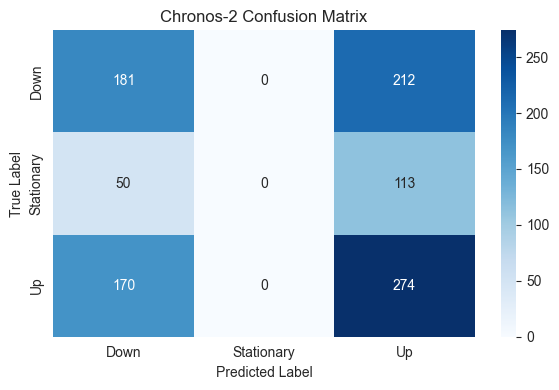


Confusion matrices saved to deeplob_vs_chronos_confusion_matrices.png


In [17]:
# ─── Confusion Matrix Visualization ───
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
class_names = ['Down', 'Stationary', 'Up']

cm = results['Chronos-2']['confusion_matrix']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title('Chronos-2 Confusion Matrix')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('deeplob_vs_chronos_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nConfusion matrices saved to deeplob_vs_chronos_confusion_matrices.png')

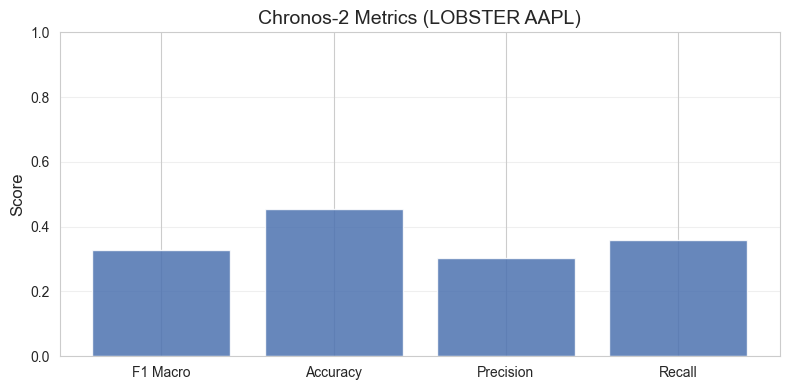

Metrics plot saved to chronos_metrics.png


In [18]:
# ─── Metric Summary Plot ───
metrics_to_plot = ['f1_macro', 'accuracy', 'precision', 'recall']
fig, ax = plt.subplots(figsize=(8, 4))
values = [results['Chronos-2'][metric] for metric in metrics_to_plot]
ax.bar([m.replace('_', ' ').title() for m in metrics_to_plot], values, color='#4C72B0', alpha=0.85)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Chronos-2 Metrics (LOBSTER AAPL)', fontsize=14)
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('chronos_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Metrics plot saved to chronos_metrics.png')

In [19]:
# ─── Classification Report ───
print('\n' + '='*70)
print('DETAILED CLASSIFICATION REPORT')
print('='*70)
print(classification_report(chronos_y_true, chronos_y_pred, target_names=class_names, zero_division=0))

# ─── Summary Table ───
summary_df = pd.DataFrame({
    'Chronos-2': {
        'F1-Macro': results['Chronos-2']['f1_macro'],
        'Accuracy': results['Chronos-2']['accuracy'],
        'Precision': results['Chronos-2']['precision'],
        'Recall': results['Chronos-2']['recall'],
        'F1 (Down)': results['Chronos-2']['f1_down'],
        'F1 (Stat)': results['Chronos-2']['f1_stat'],
        'F1 (Up)': results['Chronos-2']['f1_up'],
    }
}).T

print('\n' + '='*70)
print('SUMMARY TABLE')
print('='*70)
print(summary_df.round(4).to_string())

# Save to CSV
summary_df.to_csv('chronos_results.csv')
print('\nResults saved to chronos_results.csv')


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Down       0.45      0.46      0.46       393
  Stationary       0.00      0.00      0.00       163
          Up       0.46      0.62      0.53       444

    accuracy                           0.46      1000
   macro avg       0.30      0.36      0.33      1000
weighted avg       0.38      0.46      0.41      1000


SUMMARY TABLE
           F1-Macro  Accuracy  Precision  Recall  F1 (Down)  F1 (Stat)  F1 (Up)
Chronos-2    0.3271     0.455     0.3029  0.3592     0.4559        0.0   0.5254

Results saved to chronos_results.csv
